<h1>Objective 2</h1>
Your team will perform two related, but distinct linear regression tasks as specified below.


<h2>Linear Regression 2.1</h2>
<ol>
    <li>Build and evaluate a linear regression model that:</li>
        <ol>
            <li>predicts the goal difference between two opposing teams in FIFA World Cup 2026 matches.</li>
        </ol>
    </li>
    <li>You must compile a dataset that comprises</li>
        <ol>
            <li>104 rows</li>
            <li>each representing an actual match in the FIFA World Cup 2026. </li>
        </ol>
    </li>
    <li>Your dataset must include</li>
        <ol>
        <li>exactly eight (8) explanatory variables = 2 per group member</li>
        <li>excluding any ID field</li>
        </ol>
    </li>
    <li>You must thoughtfully decide what these explanatory variables would be and then collect their corresponding data.</li>
    </li>
</ol>

Note: All explanatory variables must provide information t
variable for predicting the goal difference of that match.

<strong>Analysis completed by Danielle Whitney</strong><br>

<em>Group 23 - HIT140 - Charles Darwin University</em><br>

<em>September 2026</em><br>


In [27]:
# import libraries for analysis question 2.1 Linear Regression
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np

# load the data files for analysis question 2.1 Linear Regression
attempts = pd.read_csv("attempts_at_goal_team.csv")
fifa_stats = pd.read_csv("FIFA_Site_Team_Stats.csv")
rounds2026 = pd.read_csv("rounds2026.csv")

In [28]:
# inspect the attempts table for data types and null values
attempts.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   rank                              48 non-null     int64  
 1   team_id                           48 non-null     int64  
 2   team                              48 non-null     str    
 3   team_abbrv                        48 non-null     str    
 4   goals                             48 non-null     int64  
 5   assists                           48 non-null     int64  
 6   attempt_at_goal                   48 non-null     int64  
 7   attempt_ontarget                  48 non-null     int64  
 8   offtarget_attempt                 48 non-null     int64  
 9   attempt_goal_convRate_percentage  48 non-null     int64  
 10  attempt_inside_pa                 48 non-null     int64  
 11  attempt_outside_pa                48 non-null     int64  
 12  headed_attempt_goal  

In [29]:
# review the attempts table
attempts.head()

,rank,team_id,team,team_abbrv,goals,assists,attempt_at_goal,attempt_ontarget,offtarget_attempt,attempt_goal_convRate_percentage,attempt_inside_pa,attempt_outside_pa,headed_attempt_goal,xG,xG_efficiency,corners,possession_control_percentage
0,1,97,Spain,ESP,14,10,140,54,59,10,79,61,22,17.48,0.8x,54,58
1,2,19,France,FRA,20,18,139,59,59,14,77,62,10,16.78,1.19x,51,51
2,3,18,England,ENG,20,14,118,52,40,17,88,30,27,15.03,1.33x,40,50
3,4,2,Argentina,ARG,19,12,115,46,49,17,66,49,22,15.45,1.23x,41,53
4,5,5,Belgium,BEL,14,10,112,35,43,13,74,38,16,10.62,1.32x,24,46


In [30]:
# inspect the attempts table for summary statistics
attempts.describe()

,rank,team_id,goals,assists,attempt_at_goal,attempt_ontarget,offtarget_attempt,attempt_goal_convRate_percentage,attempt_inside_pa,attempt_outside_pa,headed_attempt_goal,xG,corners,possession_control_percentage
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,24.187500,46.666667,6.416667,4.645833,53.562500,18.479167,22.562500,11.229167,32.583333,20.979167,8.729167,5.533333,19.812500,44.333333
std,13.822055,37.125052,5.164664,4.128209,31.169343,13.473362,12.517063,5.482039,20.544537,12.543524,5.452852,4.204746,12.156176,8.213464
min,1.000000,1.000000,0.000000,0.000000,17.000000,2.000000,5.000000,0.000000,6.000000,6.000000,2.000000,1.120000,5.000000,27.000000
25%,12.500000,12.750000,2.000000,1.750000,31.750000,8.000000,14.750000,6.000000,16.750000,12.000000,5.000000,2.340000,10.000000,37.000000
50%,24.500000,48.500000,5.000000,3.000000,44.500000,14.000000,18.000000,11.500000,26.000000,18.000000,7.000000,4.260000,16.500000,46.000000
75%,34.750000,67.250000,10.000000,7.250000,69.250000,23.750000,28.250000,14.000000,44.750000,26.000000,12.000000,7.245000,26.000000,51.000000
max,47.000000,112.000000,20.000000,18.000000,140.000000,59.000000,59.000000,25.000000,88.000000,62.000000,27.000000,17.480000,54.000000,58.000000


In [31]:
attempts_renamed = attempts.rename(columns={
    "team": "Team",
    "team_abbrv": "TeamAbbr",
    "goals": "Goals",
    "assists": "Assists",
    "attempt_at_goal": "Attempts_at_goal",
    "attempt_ontarget": "Attempts_on_target",
    "offtarget_attempt": "Off_Target_Attempts",
    "attempt_goal_convRate_percentage": "Attempts_at_goal_conversionrate(%)",
    "attempt_inside_pa": "Attempts_Inside_PenaltyArea",
    "attempt_outside_pa": "Attemps_Outside_PenaltyArea",
    "headed_attempt_goal": "Headed_Attemps_at_Goal",
    "xG": "xG",
    "xG_efficiency": "xG_Efficiency",
    "corners": "Corners",
    "possession_control_percentage": "Possession_Control(%)"
})

In [32]:
fifa_stats.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Rank                                 48 non-null     int64  
 1   Team                                 48 non-null     str    
 2   Goals                                48 non-null     int64  
 3   Assists                              48 non-null     int64  
 4   Attempts_at_goal                     48 non-null     int64  
 5   Attempts_on_target                   48 non-null     int64  
 6   Off_Target_Attempts                  48 non-null     int64  
 7   Attempts_ at_goal_conversionrate(%)  48 non-null     int64  
 8   Attempts_Inside_PenaltyArea          48 non-null     int64  
 9   Attemps_Outside_PenaltyArea          48 non-null     int64  
 10  Headed_Attemps_at_Goal               48 non-null     int64  
 11  xG                                   48 non-n

In [33]:
fifa_stats.head()

,Rank,Team,Goals,Assists,Attempts_at_goal,Attempts_on_target,Off_Target_Attempts,Attempts_ at_goal_conversionrate(%),Attempts_Inside_PenaltyArea,Attemps_Outside_PenaltyArea,Headed_Attemps_at_Goal,xG,xG_Efficiency,Corners,Possession_Control(%)
0,1,England,20,14,118,52,40,17,88,30,27,15.03,1.33,40,50
1,1,France,20,18,139,59,59,14,77,62,10,16.78,1.19,51,51
2,3,Argentina,19,12,115,46,49,17,66,49,22,15.45,1.23,41,53
3,4,Spain,14,10,140,54,59,10,79,61,22,17.48,0.80,54,58
4,4,Belgium,14,10,112,35,43,13,74,38,16,10.62,1.32,24,46


In [34]:
fifa_stats.describe()

,Rank,Goals,Assists,Attempts_at_goal,Attempts_on_target,Off_Target_Attempts,Attempts_ at_goal_conversionrate(%),Attempts_Inside_PenaltyArea,Attemps_Outside_PenaltyArea,Headed_Attemps_at_Goal,xG,xG_Efficiency,Corners,Possession_Control(%)
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,22.687500,6.416667,4.645833,53.562500,18.479167,22.562500,11.229167,32.583333,20.979167,8.729167,5.533333,1.167708,19.812500,44.333333
std,13.184705,5.164664,4.128209,31.169343,13.473362,12.517063,5.482039,20.544537,12.543524,5.452852,4.204746,0.517614,12.156176,8.213464
min,1.000000,0.000000,0.000000,17.000000,2.000000,5.000000,0.000000,6.000000,6.000000,2.000000,1.120000,0.000000,5.000000,27.000000
25%,10.000000,2.000000,1.750000,31.750000,8.000000,14.750000,6.000000,16.750000,12.000000,5.000000,2.340000,0.800000,10.000000,37.000000
50%,22.000000,5.000000,3.000000,44.500000,14.000000,18.000000,11.500000,26.000000,18.000000,7.000000,4.260000,1.210000,16.500000,46.000000
75%,35.000000,10.000000,7.250000,69.250000,23.750000,28.250000,14.000000,44.750000,26.000000,12.000000,7.245000,1.502500,26.000000,51.000000
max,48.000000,20.000000,18.000000,140.000000,59.000000,59.000000,25.000000,88.000000,62.000000,27.000000,17.480000,2.520000,54.000000,58.000000


In [35]:
rounds2026.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 104 non-null    int64
 1   voteStatus         104 non-null    str  
 2   stage              104 non-null    str  
 3   roundName          104 non-null    str  
 4   votingStartDate    104 non-null    str  
 5   votingEndDate      104 non-null    str  
 6   votingOpenedAt     104 non-null    str  
 7   selectedFormation  2 non-null      str  
 8   winners            104 non-null    str  
 9   formations         2 non-null      str  
 10  id.1               104 non-null    int64
 11  venueName          104 non-null    str  
 12  venueCity          104 non-null    str  
 13  venueId            104 non-null    int64
 14  date               104 non-null    str  
 15  homeSquadId        104 non-null    int64
 16  awaySquadId        104 non-null    int64
 17  homeSquadName      104 non-

In [36]:
rounds2026.head()

,id,voteStatus,stage,roundName,votingStartDate,votingEndDate,votingOpenedAt,selectedFormation,winners,formations,...,homeSquadId,awaySquadId,homeSquadName,awaySquadName,homeSquadAbbr,awaySquadAbbr,homeScore,awayScore,groupName,matchDay
0,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,52,96,Mexico,South Africa,MEX,RSA,2,0,A,1
1,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,51,15,Korea Republic,Czechia,KOR,CZE,2,1,A,1
2,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,9,6,Canada,Bosnia and Herzegovina,CAN,BIH,1,1,B,1
3,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,111,58,USA,Paraguay,USA,PAR,4,1,D,1
4,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,60,99,Qatar,Switzerland,QAT,SUI,1,1,B,1


In [37]:
rounds2026.describe()

,id,id.1,venueId,homeSquadId,awaySquadId,homeScore,awayScore,matchDay
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,2.903846,52.500000,8.673077,46.692308,41.692308,1.721154,1.240385,2.913462
std,1.663540,30.166206,4.425088,37.793531,35.622093,1.503761,1.234576,1.695858
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
25%,2.000000,26.750000,5.000000,12.000000,11.000000,1.000000,0.000000,2.000000
50%,3.000000,52.500000,9.000000,49.500000,33.500000,1.000000,1.000000,3.000000
75%,4.000000,78.250000,13.000000,89.250000,58.000000,3.000000,2.000000,4.000000
max,8.000000,104.000000,16.000000,112.000000,112.000000,7.000000,6.000000,9.000000


In [38]:
# import the rounds2022.csv file for analysis and possibly for use in the regression comparison to previous years "regression test"
rounds2022 = pd.read_csv("rounds2022.csv")

In [39]:
rounds2022.head()

,Round,roundName,Date,Time,homeSquadName,homeSquadAbbr,homeScore,awayScore,awaySquadName,awaySquadAbbr,Venue,penaltyShootOut
0,Group stage,Round_1,20/11/2022,19:00 (00:00),Qatar,qa,0,2,Ecuador,ec,Al Bayt Stadium (Neutral Site),NaN
1,Group stage,Round_1,21/11/2022,16:00 (21:00),England,eng,6,2,IR Iran,ir,Khalifa International Stadium (Neutral Site),NaN
2,Group stage,Round_1,21/11/2022,19:00 (00:00),Senegal,sn,0,2,Netherlands,nl,Al Thumama Stadium (Neutral Site),NaN
3,Group stage,Round_1,21/11/2022,22:00 (03:00),USA,us,1,1,Wales,wls,Ahmed bin Ali Stadium (Neutral Site),NaN
4,Group stage,Round_1,22/11/2022,13:00 (18:00),Argentina,ar,1,2,Saudi Arabia,sa,Lusail Iconic Stadium (Neutral Site),NaN


In [40]:
rounds2022.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Round            64 non-null     str  
 1   roundName        64 non-null     str  
 2   Date             64 non-null     str  
 3   Time             64 non-null     str  
 4   homeSquadName    64 non-null     str  
 5   homeSquadAbbr    64 non-null     str  
 6   homeScore        64 non-null     int64
 7   awayScore        64 non-null     int64
 8   awaySquadName    64 non-null     str  
 9   awaySquadAbbr    64 non-null     str  
 10  Venue            64 non-null     str  
 11  penaltyShootOut  5 non-null      str  
dtypes: int64(2), str(10)
memory usage: 6.1 KB


In [41]:
rounds2022.describe()

,homeScore,awayScore
count,64.000000,64.000000
mean,1.578125,1.109375
std,1.551289,1.055856
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,7.000000,4.000000


In [42]:
team_stats = attempts_renamed.copy()

In [43]:
# create matches table with only matches that have scores
matches = rounds2026.dropna(subset=["homeScore", "awayScore"].copy())

In [44]:
# review newly created table
matches.head()

,id,voteStatus,stage,roundName,votingStartDate,votingEndDate,votingOpenedAt,selectedFormation,winners,formations,...,homeSquadId,awaySquadId,homeSquadName,awaySquadName,homeSquadAbbr,awaySquadAbbr,homeScore,awayScore,groupName,matchDay
0,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,52,96,Mexico,South Africa,MEX,RSA,2,0,A,1
1,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,51,15,Korea Republic,Czechia,KOR,CZE,2,1,A,1
2,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,9,6,Canada,Bosnia and Herzegovina,CAN,BIH,1,1,B,1
3,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,111,58,USA,Paraguay,USA,PAR,4,1,D,1
4,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,60,99,Qatar,Switzerland,QAT,SUI,1,1,B,1


In [45]:
# inspect the matches table for data types and null values
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 104 non-null    int64
 1   voteStatus         104 non-null    str  
 2   stage              104 non-null    str  
 3   roundName          104 non-null    str  
 4   votingStartDate    104 non-null    str  
 5   votingEndDate      104 non-null    str  
 6   votingOpenedAt     104 non-null    str  
 7   selectedFormation  2 non-null      str  
 8   winners            104 non-null    str  
 9   formations         2 non-null      str  
 10  id.1               104 non-null    int64
 11  venueName          104 non-null    str  
 12  venueCity          104 non-null    str  
 13  venueId            104 non-null    int64
 14  date               104 non-null    str  
 15  homeSquadId        104 non-null    int64
 16  awaySquadId        104 non-null    int64
 17  homeSquadName      104 non-

In [46]:
print("Number of matches with scores: ", len(matches))

Number of matches with scores:  104


In [47]:
# create variable
matches_len = len(matches)
matches["goal_diff"] = matches["homeScore"] - matches["awayScore"]

In [48]:
fifa_stats.head()

,Rank,Team,Goals,Assists,Attempts_at_goal,Attempts_on_target,Off_Target_Attempts,Attempts_ at_goal_conversionrate(%),Attempts_Inside_PenaltyArea,Attemps_Outside_PenaltyArea,Headed_Attemps_at_Goal,xG,xG_Efficiency,Corners,Possession_Control(%)
0,1,England,20,14,118,52,40,17,88,30,27,15.03,1.33,40,50
1,1,France,20,18,139,59,59,14,77,62,10,16.78,1.19,51,51
2,3,Argentina,19,12,115,46,49,17,66,49,22,15.45,1.23,41,53
3,4,Spain,14,10,140,54,59,10,79,61,22,17.48,0.80,54,58
4,4,Belgium,14,10,112,35,43,13,74,38,16,10.62,1.32,24,46


In [49]:
# group home team
home = matches.merge(
    team_stats,
    left_on="homeSquadAbbr",
    right_on="TeamAbbr",
    how="left",
    suffixes=("", "_home")
)

In [50]:
home.head()

,id,voteStatus,stage,roundName,votingStartDate,votingEndDate,votingOpenedAt,selectedFormation,winners,formations,...,Attempts_on_target,Off_Target_Attempts,Attempts_at_goal_conversionrate(%),Attempts_Inside_PenaltyArea,Attemps_Outside_PenaltyArea,Headed_Attemps_at_Goal,xG,xG_Efficiency,Corners,Possession_Control(%)
0,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,21,32,14,44,26,13,8.10,1.23x,19,48
1,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,11,13,6,21,11,9,3.38,0.59x,12,56
2,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,31,40,5,55,39,13,7.32,0.68x,24,53
3,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,19,24,19,47,12,12,6.37,1.73x,26,52
4,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,6,10,12,10,7,2,1.88,1.06x,9,31


In [67]:
home.describe()

,id,id.1,venueId,homeSquadId,awaySquadId,homeScore,awayScore,matchDay,goal_diff,rank,...,Attempts_at_goal,Attempts_on_target,Off_Target_Attempts,Attempts_at_goal_conversionrate(%),Attempts_Inside_PenaltyArea,Attemps_Outside_PenaltyArea,Headed_Attemps_at_Goal,xG,Corners,Possession_Control(%)
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,...,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,2.903846,52.500000,8.673077,46.692308,41.692308,1.721154,1.240385,2.913462,0.480769,18.740385,...,67.528846,24.432692,28.125000,12.086538,41.615385,25.913462,10.711538,7.483365,24.490385,46.538462
std,1.663540,30.166206,4.425088,37.793531,35.622093,1.503761,1.234576,1.695858,2.024034,13.721215,...,36.807280,16.385978,14.956044,5.304533,23.137121,15.877633,6.226584,5.119553,13.677985,7.864043
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,-4.000000,1.000000,...,17.000000,2.000000,5.000000,0.000000,6.000000,6.000000,2.000000,1.120000,5.000000,27.000000
25%,2.000000,26.750000,5.000000,12.000000,11.000000,1.000000,0.000000,2.000000,-1.000000,6.750000,...,37.000000,11.000000,16.000000,8.000000,20.000000,12.000000,6.000000,2.687500,13.000000,41.750000
50%,3.000000,52.500000,9.000000,49.500000,33.500000,1.000000,1.000000,3.000000,0.000000,17.000000,...,62.000000,20.000000,25.000000,13.000000,40.000000,23.000000,10.000000,6.370000,23.000000,49.000000
75%,4.000000,78.250000,13.000000,89.250000,58.000000,3.000000,2.000000,4.000000,2.000000,29.000000,...,84.250000,31.000000,36.250000,15.000000,55.000000,30.000000,13.000000,10.620000,29.000000,52.000000
max,8.000000,104.000000,16.000000,112.000000,112.000000,7.000000,6.000000,9.000000,6.000000,47.000000,...,140.000000,59.000000,59.000000,25.000000,88.000000,62.000000,27.000000,17.480000,54.000000,58.000000


Text(0, 0.5, 'Team')

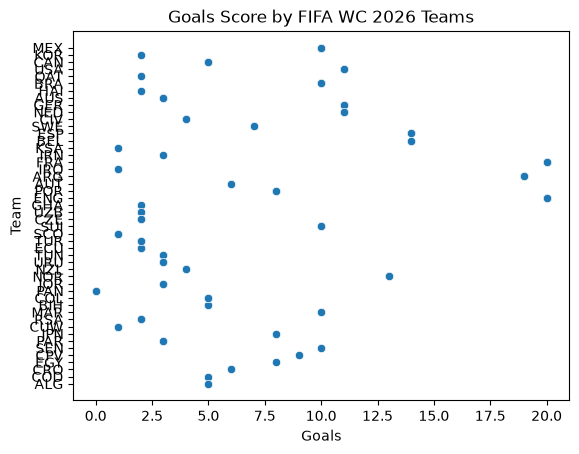

In [51]:
sns.scatterplot(y=home["TeamAbbr"], x=home["Goals"])
plt.title("Goals Score by FIFA WC 2026 Teams")
plt.xlabel("Goals")
plt.ylabel("Team")

<Axes: ylabel='Goals'>

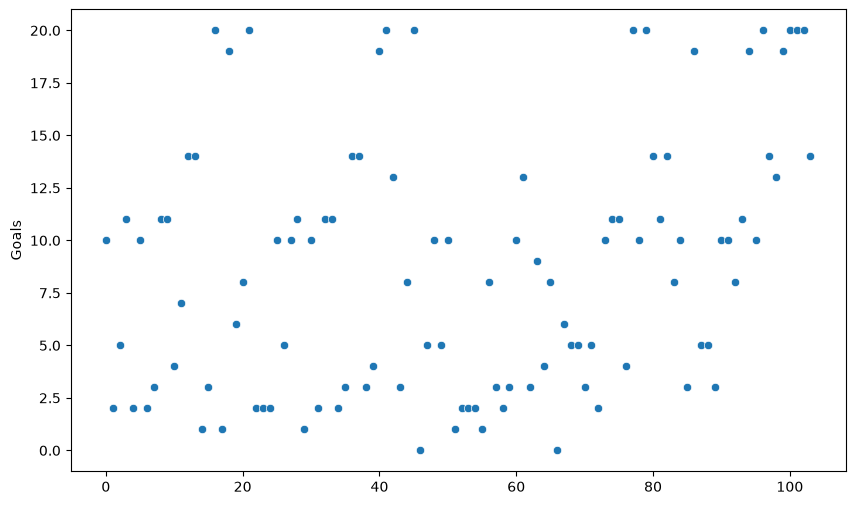

In [58]:
plt.figure(figsize=(10, 6))
sns.scatterplot(home["Goals"])

Text(0.5, 1.0, 'Distribution of Shooting Efficiency')

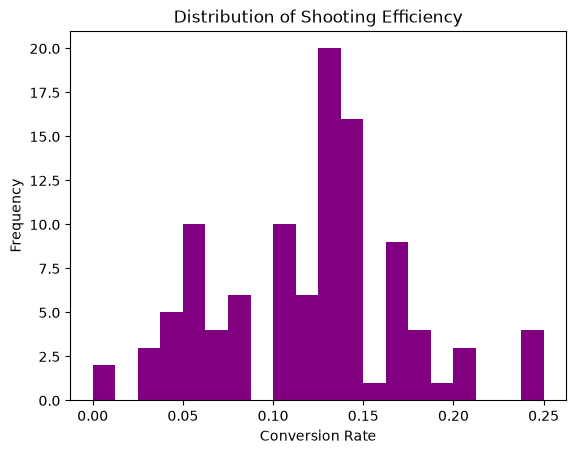

In [75]:
eff = home["Goals"] / home["Attempts_at_goal"]
plt.hist(eff, bins=20, color="purple")
plt.xlabel("Conversion Rate")
plt.ylabel("Frequency")
plt.title("Distribution of Shooting Efficiency")


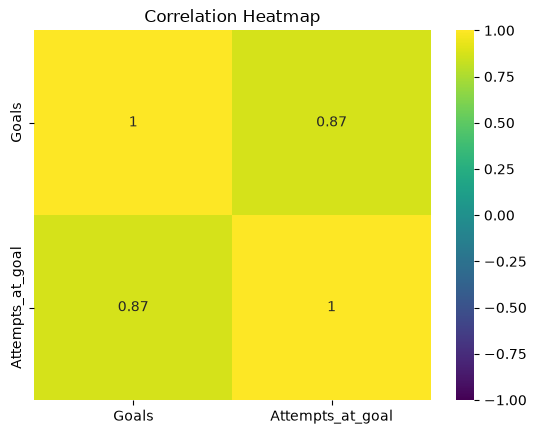

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(home[["Goals", "Attempts_at_goal"]].corr(), 
            annot=True, cmap="viridis", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()


<Axes: xlabel='Attempts_at_goal', ylabel='Goals'>

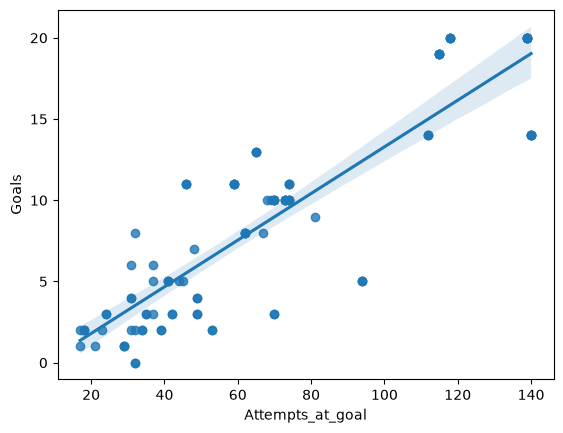

In [ ]:
sns.regplot(x=home["Attempts_at_goal"], y=home["Goals"], 
)


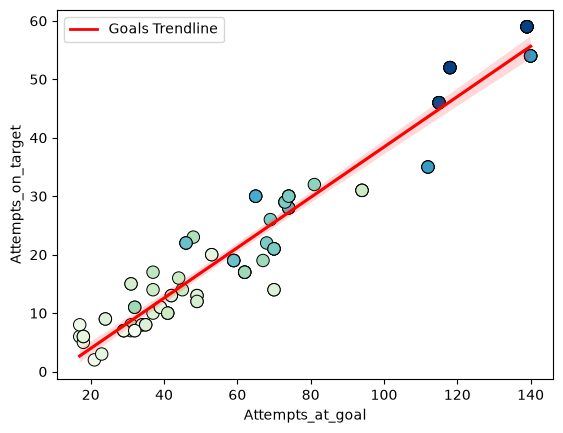

In [ ]:
# create a colour from the avg goals for use in the scatter plot
line_color = plt.cm.viridis(home["Goals"].mean() / home["Goals"].max())


ax = sns.scatterplot(
    x=home["Attempts_at_goal"],
    y=home["Attempts_on_target"],
    hue=home["Goals"],
    palette="GnBu",
    s=80,
    edgecolor="black"
)

sns.regplot(
    x=home["Attempts_at_goal"],
    y=home["Attempts_on_target"],
    scatter=False,
    line_kws={"color": "red"},
)

# Add custom legend entry for the regression line
from matplotlib.lines import Line2D

custom_line = Line2D([0], [0], color="red", lw=2)
plt.legend(handles=[custom_line], labels=["Goals Trendline"])


In [ ]:
homesample = home.goals.values
max_val = home["goals"].max()
min_val = home["goals"].min()
the_range = max_val - min_val
bin_width = 1
bin_count= int(the_range/bin_width)


In [ ]:
np.sort(homesample)

array([ 0,  0,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  4,  4,
        4,  5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  7,  8,  8,  8,  8,
        8,  8,  9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 13, 13, 13, 14, 14, 14, 14,
       14, 14, 14, 14, 19, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 20, 20,
       20, 20])

(array([ 2.,  5., 13., 11.,  4.,  9.,  2.,  1.,  6.,  1., 14., 10.,  0.,
         3.,  8.,  0.,  0.,  0.,  0., 15.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20.]),
 <BarContainer object of 20 artists>)

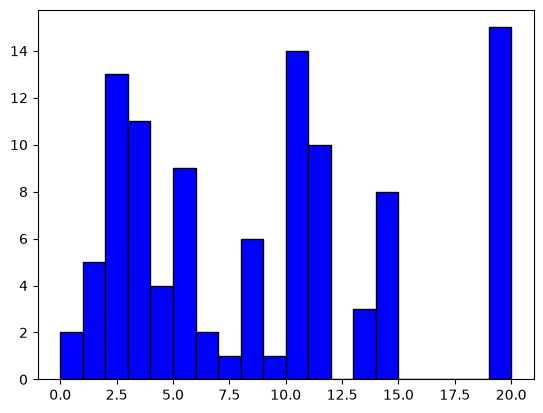

In [ ]:
plt.hist(homesample, color='blue', edgecolor='black', bins=bin_count)

In [ ]:
# Rename home columns with prefix
home_cols_map = {
    "Goals": "home_Goals",
    "Attempts_at_goal": "home_Attempts_at_goal",
    "Attempts_on_target": "home_Attempts_on_target",
    "Attempts_at_goal_conversionrate(%)": "home_ConversionRate",
    "Attempts_Inside_PenaltyArea": "home_Attempts_inside_PA",
    "Headed_Attemps_at_Goal": "home_Headed_attempts",
    "xG": "home_xG",
    "Possession_Control(%)": "home_Possession",
    "xG_Efficiency_num": "home_xG_eff"
}
home.rename(columns=home_cols_map, inplace=True)

In [ ]:
# Away stats: merge again on awaySquadAbbr
full = home.merge(
    team_stats,
    left_on="awaySquadAbbr",
    right_on="TeamAbbr",
    how="left",
    suffixes=("", "_away")
)

In [ ]:
away_cols_map = {
    "Goals": "away_Goals",
    "Attempts_at_goal": "away_Attempts_at_goal",
    "Attempts_on_target": "away_Attempts_on_target",
    "Attempts_at_goal_conversionrate(%)": "away_ConversionRate",
    "Attempts_Inside_PenaltyArea": "away_Attempts_inside_PA",
    "Headed_Attemps_at_Goal": "away_Headed_attempts",
    "xG": "away_xG",
    "Possession_Control(%)": "away_Possession",
    "xG_Efficiency_num": "away_xG_eff"
}
full.rename(columns=away_cols_map, inplace=True)

In [ ]:
# 6. Build eight explanatory variables as "home minus away"

full["diff_goals_scored"] = full["home_Goals"] - full["away_Goals"]
full["diff_attempts_at_goal"] = full["home_Attempts_at_goal"] - full["away_Attempts_at_goal"]
full["diff_attempts_on_target"] = full["home_Attempts_on_target"] - full["away_Attempts_on_target"]
full["diff_conversion_rate"] = full["home_ConversionRate"] - full["away_ConversionRate"]
full["diff_attempts_inside_pa"] = full["home_Attempts_inside_PA"] - full["away_Attempts_inside_PA"]
full["diff_headed_attempts"] = full["home_Headed_attempts"] - full["away_Headed_attempts"]
full["diff_xG"] = full["home_xG"] - full["away_xG"]
full["diff_possession"] = full["home_Possession"] - full["away_Possession"]

feature_cols = [
    "diff_goals_scored",
    "diff_attempts_at_goal",
    "diff_attempts_on_target",
    "diff_conversion_rate",
    "diff_attempts_inside_pa",
    "diff_headed_attempts",
    "diff_xG",
    "diff_possession"
]

In [ ]:
full.head()

,id,voteStatus,stage,roundName,votingStartDate,votingEndDate,votingOpenedAt,selectedFormation,winners,formations,...,Corners_away,away_Possession,diff_goals_scored,diff_attempts_at_goal,diff_attempts_on_target,diff_conversion_rate,diff_attempts_inside_pa,diff_headed_attempts,diff_xG,diff_possession
0,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,11,46,8,31,10,9,31,8,5.62,2
1,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,15,37,0,-2,3,0,-1,-1,0.94,19
2,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,15,40,0,57,17,-9,39,8,5.28,13
3,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,10,27,8,24,11,10,30,8,4.38,25
4,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,28,49,-8,-57,-24,-2,-40,-5,-7.71,-18


In [ ]:
# 7. Final dataset: 104 rows, 8 features + target

final_df = full[["goal_difference"] + feature_cols].dropna()

print("\nFinal dataset shape:", final_df.shape)
print("\nFeature list:")
for c in feature_cols:
    print("-", c)

print("\nPreview of dataset:")
print(final_df.head())